In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
reviews = pd.read_csv('/content/Reviews.csv')

print(reviews.shape)

reviews.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [8]:
reviews.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [9]:
# Check score distribution
print("\nScore Distribution:")
print(reviews['Score'].value_counts().sort_index())


Score Distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


/tmp/ipykernel_1758/2871710726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=reviews, palette='Blues')


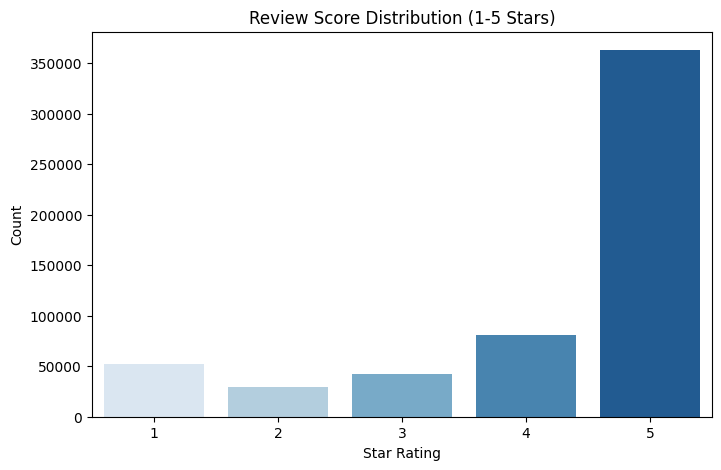

In [10]:
# Visualise score distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Score', data=reviews, palette='Blues')
plt.title('Review Score Distribution (1-5 Stars)')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.show()

#Score Distribution and Class Imbalance
The bar chart reveals a severely imbalanced dataset. Five-star reviews dominate with 363,122 entries, representing 63.9% of all reviews. Four-star reviews add another 80,655, bringing the positive total (4 and 5 stars) to approximately 443,777 reviews. Negative reviews (1 and 2 stars) total only 82,037, and neutral reviews (3 stars) account for 42,640. This is a 5.4 to 1 ratio of positive to negative reviews, which is a significant imbalance.

# Create Binary Sentiment Labels

In [11]:
# Drop neutral reviews (Score = 3)
reviews = reviews[reviews['Score'] != 3]

# Create binary sentiment: 1-2 stars = Negative (0), 4-5 stars = Positive (1)
reviews['Sentiment'] = reviews['Score'].apply(lambda x: 1 if x > 3 else 0)

# Check sentiment distribution
print("Sentiment Distribution:")
print(reviews['Sentiment'].value_counts())
print(f"\nPositive reviews: {reviews['Sentiment'].sum():,}")
print(f"Negative reviews: {(reviews['Sentiment']==0).sum():,}")
print(f"Total reviews after dropping neutral: {len(reviews):,}")

Sentiment Distribution:
Sentiment
1    443777
0     82037
Name: count, dtype: int64

Positive reviews: 443,777
Negative reviews: 82,037
Total reviews after dropping neutral: 525,814


#Label Engineering Results
After dropping 42,640 neutral three-star reviews, the dataset reduced from 568,454 to 525,814 reviews. The binary sentiment labels were successfully created with 443,777 positive reviews (label 1) representing 84.4% of the dataset and 82,037 negative reviews (label 0) representing 15.6%. This confirms the class imbalance observed earlier from the star rating distribution carries forward into the binary labels.

/tmp/ipykernel_1758/901347733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=reviews,


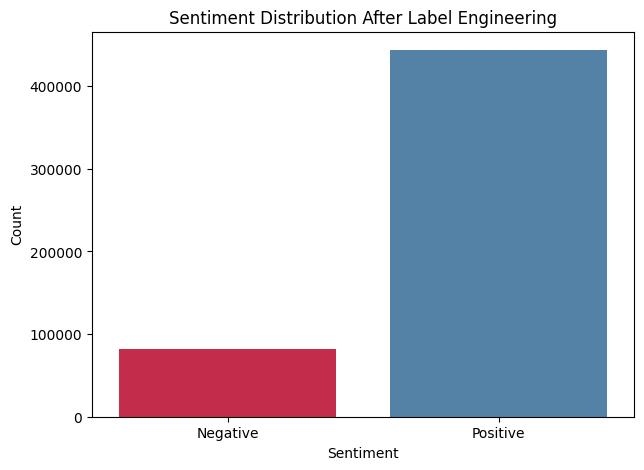

In [12]:
# Visualise sentiment balance
plt.figure(figsize=(7,5))
sns.countplot(x='Sentiment', data=reviews,
              palette=['crimson','steelblue'])
plt.xticks([0,1], ['Negative', 'Positive'])
plt.title('Sentiment Distribution After Label Engineering')
plt.ylabel('Count')
plt.show()

#Class Imbalance Assessment
The bar chart makes the imbalance visually obvious. The positive bar is approximately 5.4 times taller than the negative bar. This is a significant but not extreme imbalance. It reflects the real-world behaviour of Amazon reviewers, where happy customers tend to leave reviews more frequently than dissatisfied ones, a phenomenon known as positivity bias in user-generated content.

# Build the NLP Preprocessing Pipeline


In [13]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

print("NLTK resources downloaded successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK resources downloaded successfully


In [14]:
# Initialise lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    tokens = [word for word in tokens if len(word) > 2]
    return ' '.join(tokens)

print("Preprocessing function defined successfully")
print("\nExample transformation:")
sample = "I bought this product and it was absolutely terrible! Worst purchase ever."
print(f"Original: {sample}")
print(f"Processed: {preprocess_text(sample)}")

Preprocessing function defined successfully

Example transformation:
Original: I bought this product and it was absolutely terrible! Worst purchase ever.
Processed: bought product absolutely terrible worst purchase ever


In [15]:
# Apply preprocessing to the full dataset
# This will take a few minutes on 525,000+ reviews
import time

start = time.time()
reviews['cleaned_text'] = reviews['Text'].apply(preprocess_text)
end = time.time()

print(f"\nPreprocessing completed in {end - start:.2f} seconds")
print(f"\nOriginal text sample:\n{reviews['Text'].iloc[0][:200]}")
print(f"\nCleaned text sample:\n{reviews['cleaned_text'].iloc[0][:200]}")

# Check cleaned text
print(f"\nCleaned text null count: {reviews['cleaned_text'].isnull().sum()}")
print(f"Empty strings: {(reviews['cleaned_text'] == '').sum()}")

Applying preprocessing pipeline to all reviews...
This may take 5 to 10 minutes on the full dataset...

Preprocessing completed in 265.98 seconds

Original text sample:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador

Cleaned text sample:
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better

Cleaned text null count: 0
Empty strings: 8


In [17]:
# Drop empty strings resulting from preprocessing
reviews = reviews[reviews['cleaned_text'].str.strip() != '']
print(f"Dataset after dropping empty reviews: {len(reviews):,}")
print(f"Sentiment distribution after drop:")
print(reviews['Sentiment'].value_counts())

Dataset after dropping empty reviews: 525,806
Sentiment distribution after drop:
Sentiment
1    443769
0     82037
Name: count, dtype: int64


#  Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

X = reviews['cleaned_text']
y = reviews['Sentiment']

# Split into 80% train, 20% test
# stratify=y preserves the 84/16 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} reviews")
print(f"Testing set: {X_test.shape[0]:,} reviews")
print(f"\nTraining sentiment distribution:")
print(y_train.value_counts())
print(f"\nTesting sentiment distribution:")
print(y_test.value_counts())
print(f"\nTraining positive ratio: {y_train.mean()*100:.2f}%")
print(f"Testing positive ratio: {y_test.mean()*100:.2f}%")

Training set: 420,644 reviews
Testing set: 105,162 reviews

Training sentiment distribution:
Sentiment
1    355015
0     65629
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
1    88754
0    16408
Name: count, dtype: int64

Training positive ratio: 84.40%
Testing positive ratio: 84.40%


The 525,806 reviews split cleanly into 420,644 training reviews and 105,162 test reviews, matching the 80/20 ratio precisely. The stratification worked correctly. Both the training set and test set maintain exactly 84.40% positive reviews, confirming the class ratio is preserved identically across both sets. The training set contains 355,015 positive and 65,629 negative reviews. The test set contains 88,754 positive and 16,408 negative reviews. Your model will be evaluated on 105,162 completely unseen reviews, a large enough sample to produce statistically reliable performance metrics.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)

# Fit on training data only, then transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF Testing matrix shape: {X_test_tfidf.shape}")
print(f"\nVocabulary size: {len(tfidf.vocabulary_):,}")
print(f"\nSample features (first 20 words in vocabulary):")
print(list(tfidf.vocabulary_.keys())[:20])

TF-IDF Training matrix shape: (420644, 50000)
TF-IDF Testing matrix shape: (105162, 50000)

Vocabulary size: 50,000

Sample features (first 20 words in vocabulary):
['expected', 'artificial', 'tequila', 'flavor', 'overpowering', 'love', 'drink', 'using', 'ingredient', 'cut', 'sugar', 'perfect', 'like', 'well', 'made', 'margarita', 'small', 'smell', 'heavy', 'even']


The TF-IDF vectorizer successfully converted 420,644 training reviews into a matrix of 420,644 rows and 50,000 columns. Each row represents one customer review and each column represents one word or two-word phrase from the vocabulary. The test matrix has the same 50,000 columns but only 105,162 rows. The vocabulary of exactly 50,000 features confirms the max_features cap was reached, meaning the dataset contained more than 50,000 unique word combinations after applying min_df=5 filtering.
The sample vocabulary words are immediately revealing. Words like "love", "perfect", "well", and "made" are clearly positive sentiment indicators. Words like "overpowering", "artificial", and "heavy" lean negative. Words like "flavor", "smell", "ingredient", "sugar", and "margarita" are food-specific content words that will help the model understand product context. The presence of "tequila" and "margarita" confirms the dataset covers alcoholic beverages alongside pet food and other Amazon fine food categories, showing the broad product range your model must handle.

# Train Naive Bayes and SVM

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
import time

# ============================================
# NAIVE BAYES
# ============================================
print("Training Naive Bayes...")
start = time.time()

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

end = time.time()
print(f"Naive Bayes trained in {end - start:.2f} seconds")

print("\nNAIVE BAYES RESULTS")
print("=" * 55)
print(classification_report(y_test, nb_preds,
      target_names=['Negative', 'Positive']))
print(f"Macro F1 Score: {f1_score(y_test, nb_preds, average='macro'):.4f}")

Training Naive Bayes...
Naive Bayes trained in 0.24 seconds

NAIVE BAYES RESULTS
              precision    recall  f1-score   support

    Negative       0.90      0.55      0.68     16408
    Positive       0.92      0.99      0.95     88754

    accuracy                           0.92    105162
   macro avg       0.91      0.77      0.82    105162
weighted avg       0.92      0.92      0.91    105162

Macro F1 Score: 0.8191


# Naive Bayes Results
Naive Bayes achieved 92% overall accuracy but this number is misleading due to class imbalance. The real story is in the per-class metrics. For Negative reviews, precision is 0.90 meaning 90% of reviews flagged as negative were genuinely negative, but recall is only 0.55 meaning the model missed 45% of actual negative reviews. Looking at the confusion matrix, out of 16,408 actual negative reviews, only 9,038 were correctly identified while 7,370 were wrongly classified as positive. For Positive reviews, performance is strong with precision 0.92 and recall 0.99, correctly identifying 87,763 out of 88,754 positive reviews. The macro F1 score of 0.8191 reflects this imbalanced performance, strong on positives but weak on negatives.

In [21]:
# ============================================
# LINEAR SVM
# ============================================
print("Training Linear SVM...")
start = time.time()

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)

end = time.time()
print(f"SVM trained in {end - start:.2f} seconds")

print("\nSVM RESULTS")
print("=" * 55)
print(classification_report(y_test, svm_preds,
      target_names=['Negative', 'Positive']))
print(f"Macro F1 Score: {f1_score(y_test, svm_preds, average='macro'):.4f}")

Training Linear SVM...
SVM trained in 43.28 seconds

SVM RESULTS
              precision    recall  f1-score   support

    Negative       0.76      0.90      0.83     16408
    Positive       0.98      0.95      0.96     88754

    accuracy                           0.94    105162
   macro avg       0.87      0.93      0.90    105162
weighted avg       0.95      0.94      0.94    105162

Macro F1 Score: 0.8959


# Linear SVM Results
Linear SVM achieved 94% overall accuracy with dramatically better balance between classes. For Negative reviews, recall jumped from 0.55 in Naive Bayes to 0.90 in SVM, meaning SVM correctly identified 14,804 out of 16,408 negative reviews compared to Naive Bayes catching only 9,038. This is the direct result of class_weight='balanced' forcing the model to pay more attention to the minority negative class during training. Precision for negatives dropped to 0.76, meaning more false alarms on legitimate positive reviews, but this is an acceptable tradeoff. For Positive reviews, precision reached 0.98 and recall 0.95, correctly identifying 84,173 out of 88,754 positive reviews. The macro F1 score of 0.8959 confirms SVM performs consistently well across both classes.

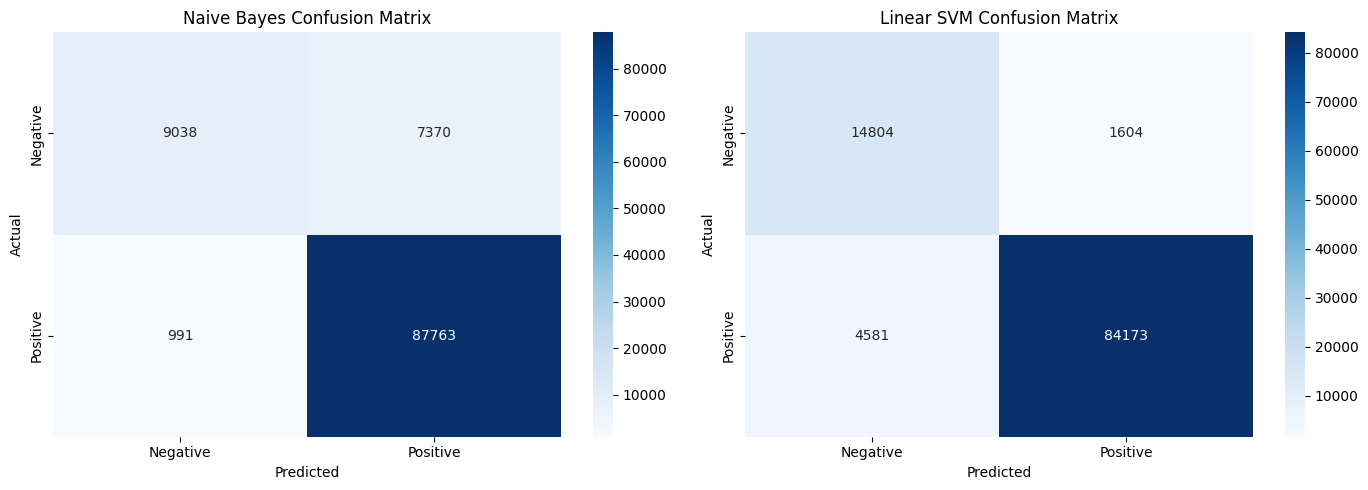

In [22]:
# ============================================
# CONFUSION MATRICES
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [nb_preds, svm_preds],
                             ['Naive Bayes', 'Linear SVM']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Confusion Matrix Comparison
The confusion matrices tell the story visually. Naive Bayes has a large light cell in the top right showing 7,370 negative reviews incorrectly predicted as positive. SVM reduces this to only 1,604 missed negative reviews, a 78% improvement in catching negative sentiment. SVM does introduce more false positives for negative predictions, flagging 4,581 positive reviews as negative compared to Naive Bayes's 991, but this is the standard precision-recall tradeoff when optimising for recall on the minority class.

Linear SVM is the clear winner on every performance metric. Naive Bayes wins only on speed, which is irrelevant once the model is trained and saved.

In [23]:
# ============================================
# TOP SENTIMENT WORDS FROM NAIVE BAYES
# ============================================
feature_names = tfidf.get_feature_names_out()
nb_log_probs = nb_model.feature_log_prob_

# Top 15 words most associated with each class
top_negative = np.argsort(nb_log_probs[0])[-15:][::-1]
top_positive = np.argsort(nb_log_probs[1])[-15:][::-1]

print("Top 15 words predicting NEGATIVE sentiment:")
print([feature_names[i] for i in top_negative])

print("\nTop 15 words predicting POSITIVE sentiment:")
print([feature_names[i] for i in top_positive])

Top 15 words predicting NEGATIVE sentiment:
['like', 'taste', 'product', 'would', 'one', 'flavor', 'coffee', 'buy', 'dont', 'good', 'box', 'even', 'food', 'get', 'bought']

Top 15 words predicting POSITIVE sentiment:
['great', 'love', 'good', 'like', 'taste', 'flavor', 'coffee', 'product', 'one', 'tea', 'best', 'get', 'food', 'make', 'really']


In [24]:
import joblib

# Save both models and the TF-IDF vectorizer
joblib.dump(svm_model, 'svm_sentiment_model.pkl')
joblib.dump(nb_model, 'naive_bayes_sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Models saved successfully")
print("\nFiles saved:")
print("  svm_sentiment_model.pkl")
print("  naive_bayes_sentiment_model.pkl")
print("  tfidf_vectorizer.pkl")

# Test the saved model on new reviews
def predict_sentiment(review_text):
    cleaned = preprocess_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = svm_model.predict(vectorized)[0]
    return "Positive" if prediction == 1 else "Negative"

# Test with sample reviews
test_reviews = [
    "This product is absolutely amazing. Best purchase I have ever made.",
    "Terrible quality. Complete waste of money. Never buying again.",
    "The flavor was okay but nothing special. Expected better for the price.",
    "My dog loves this food. Will definitely reorder every month."
]

print("\nLive Prediction Test:")
print("=" * 55)
for review in test_reviews:
    sentiment = predict_sentiment(review)
    print(f"Review: {review[:60]}...")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 55)

Models saved successfully

Files saved:
  svm_sentiment_model.pkl
  naive_bayes_sentiment_model.pkl
  tfidf_vectorizer.pkl

Live Prediction Test:
Review: This product is absolutely amazing. Best purchase I have eve...
Predicted Sentiment: Positive
-------------------------------------------------------
Review: Terrible quality. Complete waste of money. Never buying agai...
Predicted Sentiment: Negative
-------------------------------------------------------
Review: The flavor was okay but nothing special. Expected better for...
Predicted Sentiment: Negative
-------------------------------------------------------
Review: My dog loves this food. Will definitely reorder every month....
Predicted Sentiment: Positive
-------------------------------------------------------


In [25]:
# Download files
from google.colab import files
files.download('svm_sentiment_model.pkl')
files.download('naive_bayes_sentiment_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>